#### some plots to illustrate concepts for slides

In [2]:
from PySDM import Formulae
from PySDM.physics import si
from PySDM_examples.Singer_organics.aerosol import AerosolBetaCaryophylleneDark
from PySDM_examples.Singer_organics.constants_def import SINGER_CONSTS, plot_colors, plot_lines, plot_names

import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot

In [14]:
formulae_bulk = Formulae(surface_tension='Constant', constants=SINGER_CONSTS)
r_dry = 50
aerosol = AerosolBetaCaryophylleneDark(Forg=0.5, r_a=r_dry, water_molar_volume=formulae_bulk.constants.water_molar_volume)
formulae_ovad = Formulae(
    surface_tension='CompressedFilmOvadnevaite',
    constants={
        'sgm_org': 40 * si.mN / si.m,
        'delta_min': 50 * si.nm,
        **SINGER_CONSTS
    }
)

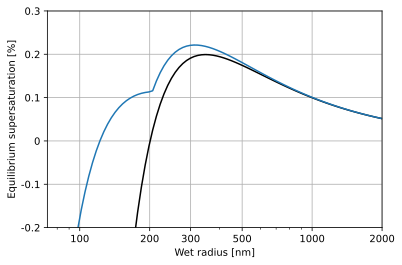

HTML(value="<a href='./kohler.pdf' target='_blank'>./kohler.pdf</a><br>")

In [39]:
for formulae in (formulae_bulk, formulae_ovad):    
    r_wet = np.logspace(np.log(50 * si.nm), np.log(2000 * si.nm), base=np.e, num=100)
    sigma = np.ones(len(r_wet))
    for j,vw in enumerate(formulae_ovad.trivia.volume(r_wet)):
        sigma[j] = formulae.surface_tension.sigma(
            300 * si.K,
            vw,
            formulae_ovad.trivia.volume(r_dry * si.nm),
            aerosol.modes[0]['f_org']
        )
    RH_eq = formulae.hygroscopicity.RH_eq(
        r_wet,
        300 * si.K,
        aerosol.modes[0]['kappa'][formulae.surface_tension.__name__],
        (r_dry * si.nm)**3,
        sigma
    )
    model = formulae.surface_tension.__name__
    pyplot.plot(
        r_wet / si.nm,
        (RH_eq - 1)*100,
        label=plot_names[model],
        color=plot_colors[model],
        linestyle="-"
    )
pyplot.grid()
# pyplot.legend(loc=0)
pyplot.xscale('log')
r_wet_ticks_nm = (100, 200, 300, 500, 1000, 2000)
pyplot.xticks(r_wet_ticks_nm, r_wet_ticks_nm)
pyplot.xlim(r_wet[10] / si.nm, r_wet[-1] / si.nm)
pyplot.ylabel('Equilibrium supersaturation [%]')
yticks = (-.2, -.1, 0, .1, .2, .3)
pyplot.yticks(yticks, yticks)
pyplot.ylim(yticks[0], .3)
pyplot.xlabel('Wet radius [nm]')
show_plot("kohler.pdf")

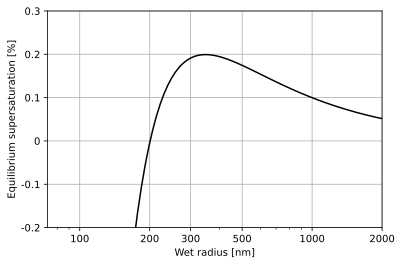

HTML(value="<a href='./kohler0.pdf' target='_blank'>./kohler0.pdf</a><br>")

In [40]:
for formulae in (formulae_bulk, ):    
    r_wet = np.logspace(np.log(50 * si.nm), np.log(2000 * si.nm), base=np.e, num=100)
    sigma = np.ones(len(r_wet))
    for j,vw in enumerate(formulae_ovad.trivia.volume(r_wet)):
        sigma[j] = formulae.surface_tension.sigma(
            300 * si.K,
            vw,
            formulae_ovad.trivia.volume(r_dry * si.nm),
            aerosol.modes[0]['f_org']
        )
    RH_eq = formulae.hygroscopicity.RH_eq(
        r_wet,
        300 * si.K,
        aerosol.modes[0]['kappa'][formulae.surface_tension.__name__],
        (r_dry * si.nm)**3,
        sigma
    )
    model = formulae.surface_tension.__name__
    pyplot.plot(
        r_wet / si.nm,
        (RH_eq - 1)*100,
        label=plot_names[model],
        color=plot_colors[model],
        linestyle=plot_lines[model]
    )
pyplot.grid()
# pyplot.legend(loc=0)
pyplot.xscale('log')
r_wet_ticks_nm = (100, 200, 300, 500, 1000, 2000)
pyplot.xticks(r_wet_ticks_nm, r_wet_ticks_nm)
pyplot.xlim(r_wet[10] / si.nm, r_wet[-1] / si.nm)
pyplot.ylabel('Equilibrium supersaturation [%]')
yticks = (-.2, -.1, 0, .1, .2, .3)
pyplot.yticks(yticks, yticks)
pyplot.ylim(yticks[0], .3)
pyplot.xlabel('Wet radius [nm]')
show_plot("kohler0.pdf")

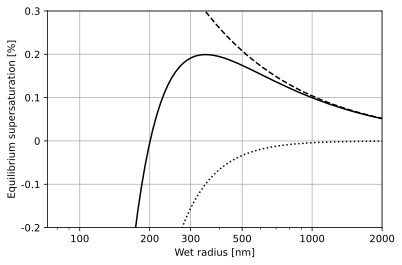

HTML(value="<a href='./kohler_terms.pdf' target='_blank'>./kohler_terms.pdf</a><br>")

In [41]:
for formulae in (formulae_bulk, ):    
    r_wet = np.logspace(np.log(50 * si.nm), np.log(2000 * si.nm), base=np.e, num=100)
    sigma = np.ones(len(r_wet))
    for j,vw in enumerate(formulae_ovad.trivia.volume(r_wet)):
        sigma[j] = formulae.surface_tension.sigma(
            300 * si.K,
            vw,
            formulae_ovad.trivia.volume(r_dry * si.nm),
            aerosol.modes[0]['f_org']
        )
    RH_eq = formulae.hygroscopicity.RH_eq(
        r_wet,
        300 * si.K,
        aerosol.modes[0]['kappa'][formulae.surface_tension.__name__],
        (r_dry * si.nm)**3,
        sigma
    )

    solute = formulae.hygroscopicity.RH_eq(
        r_wet,
        300 * si.K,
        aerosol.modes[0]['kappa'][formulae.surface_tension.__name__],
        (r_dry * si.nm)**3,
        0.0
    )
    curvature = formulae.hygroscopicity.RH_eq(
        r_wet,
        300 * si.K,
        0.0,
        (r_dry * si.nm)**3,
        sigma
    )

    model = formulae.surface_tension.__name__
    pyplot.plot(
        r_wet / si.nm,
        (RH_eq - 1)*100,
        label=plot_names[model],
        color=plot_colors[model],
        linestyle=plot_lines[model]
    )
    pyplot.plot(
        r_wet / si.nm,
        (solute - 1)*100,
        color="k",
        linestyle=":"
    )
    pyplot.plot(
        r_wet / si.nm,
        (curvature - 1)*100,
        color="k",
        linestyle="--"
    )

pyplot.grid()
# pyplot.legend(loc=0)
pyplot.xscale('log')
r_wet_ticks_nm = (100, 200, 300, 500, 1000, 2000)
pyplot.xticks(r_wet_ticks_nm, r_wet_ticks_nm)
pyplot.xlim(r_wet[10] / si.nm, r_wet[-1] / si.nm)
pyplot.ylabel('Equilibrium supersaturation [%]')
yticks = (-.2, -.1, 0, .1, .2, .3, .4, .5)
pyplot.yticks(yticks, yticks)
pyplot.ylim(yticks[0], .3)
pyplot.xlabel('Wet radius [nm]')
show_plot("kohler_terms.pdf")